## Project Title: Automated Gender Identification for Intelligent Call Center Chatbots & Virtual Assistants

### Problem Statement
Call center audio processing pipelines lack a lightweight, automated mechanism to accurately classify caller demographics (male vs. female) in real-time from acoustic properties of their speech. Existing generic models often suffer from inefficiency due to unstandardized audio features, high dimensionality, or unoptimized classifier parameters, leading to misclassification and degraded user experience during automated customer interactions.

## Import Libraries and Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
data = pd.read_csv('voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [ ]:
data.shape

(3168, 21)

## Correlation Check

In [ ]:
corrmat = data.corr()
corrmat

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
meanfreq,1.000000,-0.739039,0.925445,0.911416,0.740997,-0.627605,-0.322327,-0.316036,-0.601203,-0.784332,0.687715,1.000000,0.460844,0.383937,0.274004,0.536666,0.229261,0.519528,0.515570,-0.216979
sd,-0.739039,1.000000,-0.562603,-0.846931,-0.161076,0.874660,0.314597,0.346241,0.716620,0.838086,-0.529150,-0.739039,-0.466281,-0.345609,-0.129662,-0.482726,-0.357667,-0.482278,-0.475999,0.122660
median,0.925445,-0.562603,1.000000,0.774922,0.731849,-0.477352,-0.257407,-0.243382,-0.502005,-0.661690,0.677433,0.925445,0.414909,0.337602,0.251328,0.455943,0.191169,0.438919,0.435621,-0.213298
Q25,0.911416,-0.846931,0.774922,1.000000,0.477140,-0.874189,-0.319475,-0.350182,-0.648126,-0.766875,0.591277,0.911416,0.545035,0.320994,0.199841,0.467403,0.302255,0.459683,0.454394,-0.141377
Q75,0.740997,-0.161076,0.731849,0.477140,1.000000,0.009636,-0.206339,-0.148881,-0.174905,-0.378198,0.486857,0.740997,0.155091,0.258002,0.285584,0.359181,-0.023750,0.335114,0.335648,-0.216475
IQR,-0.627605,0.874660,-0.477352,-0.874189,0.009636,1.000000,0.249497,0.316185,0.640813,0.663601,-0.403764,-0.627605,-0.534462,-0.222680,-0.069588,-0.333362,-0.357037,-0.337877,-0.331563,0.041252
skew,-0.322327,0.314597,-0.257407,-0.319475,-0.206339,0.249497,1.000000,0.977020,-0.195459,0.079694,-0.434859,-0.322327,-0.167668,-0.216954,-0.080861,-0.336848,-0.061608,-0.305651,-0.304640,-0.169325
kurt,-0.316036,0.346241,-0.243382,-0.350182,-0.148881,0.316185,0.977020,1.000000,-0.127644,0.109884,-0.406722,-0.316036,-0.194560,-0.203201,-0.045667,-0.303234,-0.103313,-0.274500,-0.272729,-0.205539
sp.ent,-0.601203,0.716620,-0.502005,-0.648126,-0.174905,0.640813,-0.195459,-0.127644,1.000000,0.866411,-0.325298,-0.601203,-0.513194,-0.305826,-0.120738,-0.293562,-0.294869,-0.324253,-0.319054,0.198074
sfm,-0.784332,0.838086,-0.661690,-0.766875,-0.378198,0.663601,0.079694,0.109884,0.866411,1.000000,-0.485913,-0.784332,-0.421066,-0.362100,-0.192369,-0.428442,-0.289593,-0.436649,-0.431580,0.211477


In [14]:
data_c= data.drop(columns=('label'))

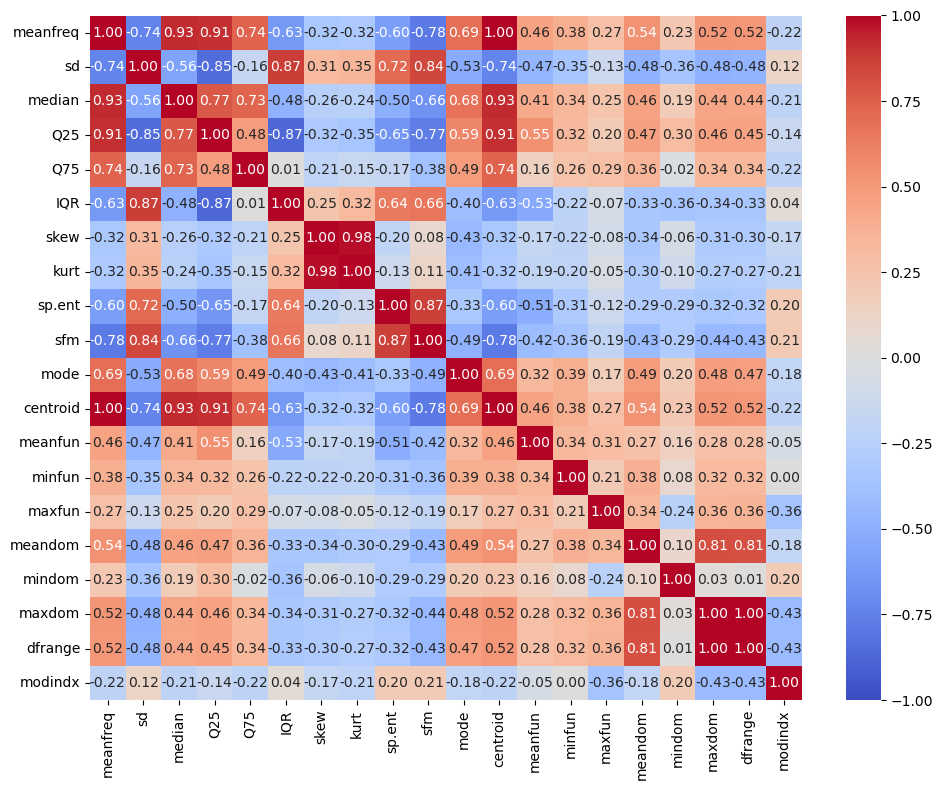

In [26]:
#Plot heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    data_c.corr(),
    annot=True,          # Display numeric correlation values in cells
    fmt='.2f',           # Round values to 2 decimal places
    cmap='coolwarm',     # Red-blue color gradient
    vmin=-1, vmax=1)    # Fix scale between -1 and 1

plt.tight_layout()
plt.show()
    

#### meanfun (Mean Fundamental Frequency): Has the strongest correlation with the target label (gender). Female voices consistently show significantly higher mean fundamental frequencies than male voices.

#### IQR (Interquartile Range) & Q25: Show strong correlations with gender—male voices generally exhibit higher spectral variation/dispersion in lower frequencies.2. Redundant & Highly Collinear Features

#### Frequency Band Parameters: Variables like meanfreq, median, Q25, and centroid show high positive correlation with one another ($r > 0.80$). They essentially capture the same underlying acoustic pitch data.

### Dimensionality Reduction Opportunity: Because many frequency-based features are highly collinear, keeping every variable is unnecessary

## Null Values Check

In [ ]:
data.isnull().sum()

meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64

In [ ]:
print('Total no of rows: %d'%data.shape[0])
print('Total no of male: %d'%(data[data['label']=='male'].shape[0]))
print('Total no of female: %d'%(data[data['label']=='female'].shape[0]))

Total no of rows: 3168
Total no of male: 1584
Total no of female: 1584


## Feature Selection

In [ ]:
X = data.iloc[:,:-1]
y = data.iloc[:,-1:]
X.head(3)
y.head(3)

,label
0,male
1,male
2,male


## Scaling and Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
gender_encoder = LabelEncoder()
y = gender_encoder.fit_transform(y)
y

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:235: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
# scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
print(X)

[[-4.04924806  0.4273553  -4.22490077 ... -1.43142165 -1.41913712
  -1.45477229]
 [-3.84105325  0.6116695  -3.99929342 ... -1.41810716 -1.4058184
  -1.01410294]
 [-3.46306647  1.60384791 -4.09585052 ... -1.42920257 -1.41691733
  -1.06534356]
 ...
 [-1.29877326  2.32272355 -0.05197279 ... -0.5992661  -0.58671739
   0.17588664]
 [-1.2452018   2.012196   -0.01772849 ... -0.41286326 -0.40025537
   1.14916112]
 [-0.51474626  2.14765111 -0.07087873 ... -1.27608595 -1.2637521
   1.47567886]]


## Train_Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

## SVM with Default Hyper-Parameter

In [ ]:
from sklearn.svm import SVC
from sklearn import metrics
svc = SVC()
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.9747634069400631


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


## Linear Kernal

In [ ]:
svc = SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.9652996845425867


## Polynomial Kernal

In [ ]:
svc = SVC(kernel='poly')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.9589905362776026


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


## Optimization of HyperParameter C

In [ ]:
# cross-validation import from sklearn
from sklearn.model_selection import cross_val_score

C_range = list(range(1,25))
acc_score=[]
for c in C_range:
    svc = SVC(kernel='linear',C=c)
    scores = cross_val_score(svc,X,y,cv=10,scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)

[0.9694132632752168, 0.9687843324576069, 0.9687843324576069, 0.9687843324576069, 0.9690987978664118, 0.9694132632752168, 0.9690987978664118, 0.9687843324576069, 0.9684698670488018, 0.9684698670488018, 0.9684698670488018, 0.9684698670488018, 0.9681534113525991, 0.9681534113525991, 0.9681534113525991, 0.9681534113525991, 0.9678369556563966, 0.9678369556563966, 0.9678369556563966, 0.9678369556563966, 0.9681534113525991, 0.9684678767614043, 0.9684678767614043, 0.9681514210652018]


Text(0, 0.5, 'Cross-Validate Accuracy')

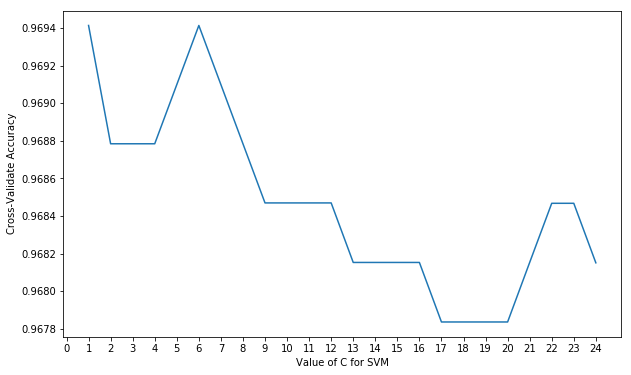

In [ ]:
plt.figure(figsize=(10,6))
C_values = list(range(1,25))
# plot C values in X-axis and cross_validate_accuracy on y-axis
plt.plot(C_values,acc_score)
plt.xticks(np.arange(0,25,1))
plt.xlabel('Value of C for SVM')
plt.ylabel('Cross-Validate Accuracy')

In [ ]:
C_range = list(np.arange(0.1,2,0.1))
acc_score=[]
for c in C_range:
    svc = SVC(kernel='linear',C=c)
    scores = cross_val_score(svc,X,y,cv=10,scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)

[0.9700481649550194, 0.9691007881538095, 0.9690987978664118, 0.9690987978664118, 0.9694132632752168, 0.9694132632752168, 0.9697277286840219, 0.9694112729878194, 0.9690968075790144, 0.9694132632752168, 0.9694132632752168, 0.9694132632752168, 0.9694132632752168, 0.9687823421702095, 0.9690987978664118, 0.9690987978664118, 0.9690987978664118, 0.9690987978664118, 0.9687843324576069]


Text(0, 0.5, 'Cross-Validate Accuracy')

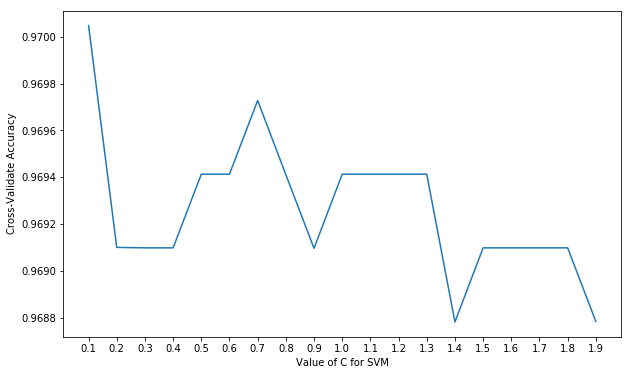

In [ ]:
plt.figure(figsize=(10,6))
C_values = list(np.arange(0.1,2,0.1))
# plot C values in X-axis and cross_validate_accuracy on y-axis
plt.plot(C_values,acc_score)
plt.xticks(np.arange(0.1,2,0.1))
plt.xlabel('Value of C for SVM')
plt.ylabel('Cross-Validate Accuracy')

## Optimization the Hyper-Parameter Gamma

In [ ]:
gamma_range = [0.0001,0.001,0.01,0.1,1,10,100]
acc_score = []
for g in gamma_range:
    svc = SVC(kernel='rbf',gamma=g)
    scores = cross_val_score(svc,X,y,cv=10,scoring='accuracy')
    acc_score.append(scores.mean())
print(acc_score)

[0.8878114799777087, 0.9552463975798107, 0.9681514210652018, 0.9630960910755512, 0.9072366849773108, 0.5955377756548046, 0.5]


Text(0, 0.5, 'Cross-Validated Accuracy')

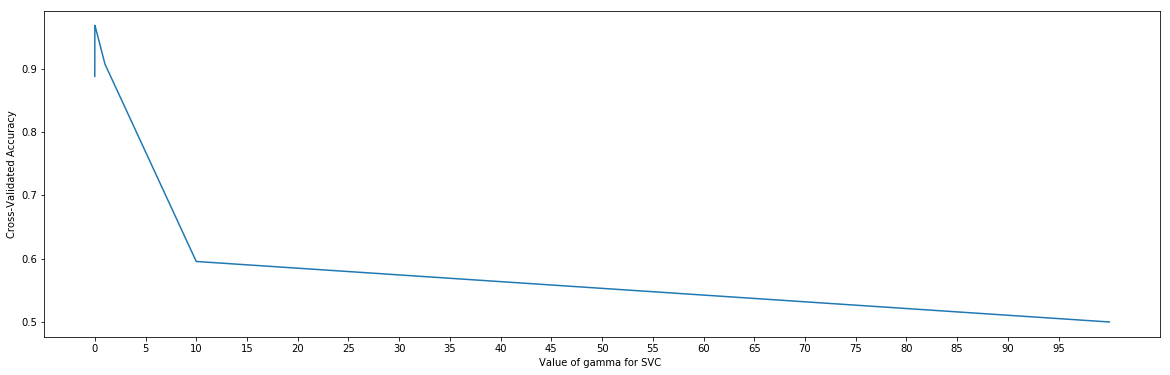

In [ ]:
%matplotlib inline
plt.figure(figsize=(20,6))
gamma_range=[0.0001,0.001,0.01,0.1,1,10,100]

# plot the value of C for SVM (x-axis) versus the cross-validated accuracy (y-axis)
plt.plot(gamma_range,acc_score)
plt.xlabel('Value of gamma for SVC ')
plt.xticks(np.arange(0.0001,100,5))
plt.ylabel('Cross-Validated Accuracy')

## Optimized Parameter from GridSearchCV

In [ ]:
tuned_parameter = {
    'C':(np.arange(0.01,1,0.01)),'kernel':['linear'],
    'C':(np.arange(0.01,1,0.01)),'gamma':[0.01,0.02,0.03,0.04,0.05],'kernel':['rbf'],
    'degree':[2,3,4,5,6], 'gamma':[0.01,0.02,0.03,0.04,0.05],'C':(np.arange(0.01,1,0.01)),'kernel':['poly']
}

In [ ]:
from sklearn.model_selection import GridSearchCV

model_svm = GridSearchCV(svc,tuned_parameter,cv=10,scoring='accuracy')

In [ ]:
model_svm.fit(X_train,y_train)
print(model_svm.best_score_)

0.9601420678768745


In [ ]:
print(model_svm.best_params_)

{'C': 0.99, 'degree': 3, 'gamma': 0.05, 'kernel': 'poly'}


In [ ]:
svc = SVC(kernel='poly',C=0.99,degree=3,gamma=0.05)
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print('Accuracy Score:')
print(metrics.accuracy_score(y_test,y_pred))

Accuracy Score:
0.9589905362776026


In [ ]:
from sklearn.metrics import confusion_matrix,classification_report,recall_score,roc_curve,precision_score,roc_auc_score
cnf_matrix = confusion_matrix(y_test,y_pred)
cnf_matrix

array([[286,  17],
       [  9, 322]], dtype=int64)

Text(0.5, 257.44, 'Predicted label')

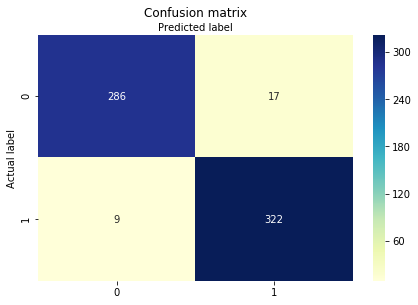

In [ ]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
recall = recall_score(y_test,y_pred)
recall

0.972809667673716

In [ ]:
precision = precision_score(y_test,y_pred)
precision

0.9498525073746312

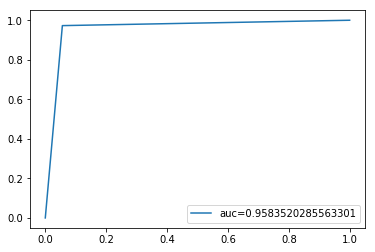

In [ ]:
fpr, tpr, _ = roc_curve(y_test,  y_pred)
auc = roc_auc_score(y_test, y_pred)
plt.plot(fpr,tpr,label="auc="+str(auc))
plt.legend(loc=4)
plt.show()

### Conclusion

#### High Accuracy: The AI model is over 95% accurate at predicting whether a caller is male or female using basic voice characteristics.

#### Key Features: Traits like average vocal pitch (meanfun) and sound frequency make it easy for the system to tell voices apart.
